# Medicare Part D Drug Spending Analysis (2019–2023)
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** CMS Medicare Part D Drug Spending Dataset  
**Tools:** Python, pandas, matplotlib

---

### Research Questions
1. Which drugs are driving total Medicare Part D spending?
2. Which drug prices have grown fastest over 5 years?
3. Which drugs create the highest cost burden per patient?
4. How does brand-name vs generic spending compare?

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load & Clean Data

In [3]:
# Load the dataset
df = pd.read_csv("Medicare_Part_D_Spending_by_Drug_2023.csv")

print(f"Full dataset shape: {df.shape}")
print(f"Manufacturers in dataset: {df['Mftr_Name'].nunique()}")

# The dataset contains an 'Overall' row per drug (aggregate across all manufacturers)
# plus individual manufacturer rows. We use 'Overall' only to avoid double-counting.
df_overall = df[df['Mftr_Name'] == 'Overall'].copy()

print(f"\nDeduped dataset shape (Overall rows only): {df_overall.shape}")
print(f"Unique drugs: {df_overall['Brnd_Name'].nunique()}")

Full dataset shape: (14309, 46)
Manufacturers in dataset: 962

Deduped dataset shape (Overall rows only): (3598, 46)
Unique drugs: 3474


## 2. Headline Summary Statistics

In [4]:
years = [2019, 2020, 2021, 2022, 2023]

total_spend_2023 = df_overall['Tot_Spndng_2023'].sum()
total_spend_2022 = df_overall['Tot_Spndng_2022'].sum()
yoy_change = ((total_spend_2023 - total_spend_2022) / total_spend_2022) * 100
total_beneficiaries = df_overall['Tot_Benes_2023'].sum()
most_expensive_drug = df_overall.loc[
    df_overall['Avg_Spnd_Per_Dsg_Unt_Wghtd_2023'].idxmax(), 'Brnd_Name'
]

print(f"Total Medicare Part D Spend (2023): ${total_spend_2023/1e9:.2f} Billion")
print(f"Total Medicare Part D Spend (2022): ${total_spend_2022/1e9:.2f} Billion")
print(f"Year-over-Year Change:              {yoy_change:.1f}%")
print(f"Total Beneficiaries (2023):         {total_beneficiaries/1e6:.1f} Million*")
print(f"Most Expensive Drug Per Dose:       {most_expensive_drug}")
print("\n* Note: Beneficiary count reflects drug-level records, not unique patients.")

# Insight
# Medicare Part D spending grew 14.8% in a single year (2022-2023),
# adding $35 billion in costs. The most expensive drug per dose is Amvuttra,
# a gene-silencing therapy for a rare hereditary disease costing ~$400K/year per patient.

Total Medicare Part D Spend (2023): $275.92 Billion
Total Medicare Part D Spend (2022): $240.31 Billion
Year-over-Year Change:              14.8%
Total Beneficiaries (2023):         478.6 Million*
Most Expensive Drug Per Dose:       Amvuttra

* Note: Beneficiary count reflects drug-level records, not unique patients.


## 3. Top 20 Drugs by Total Medicare Spend (2023)

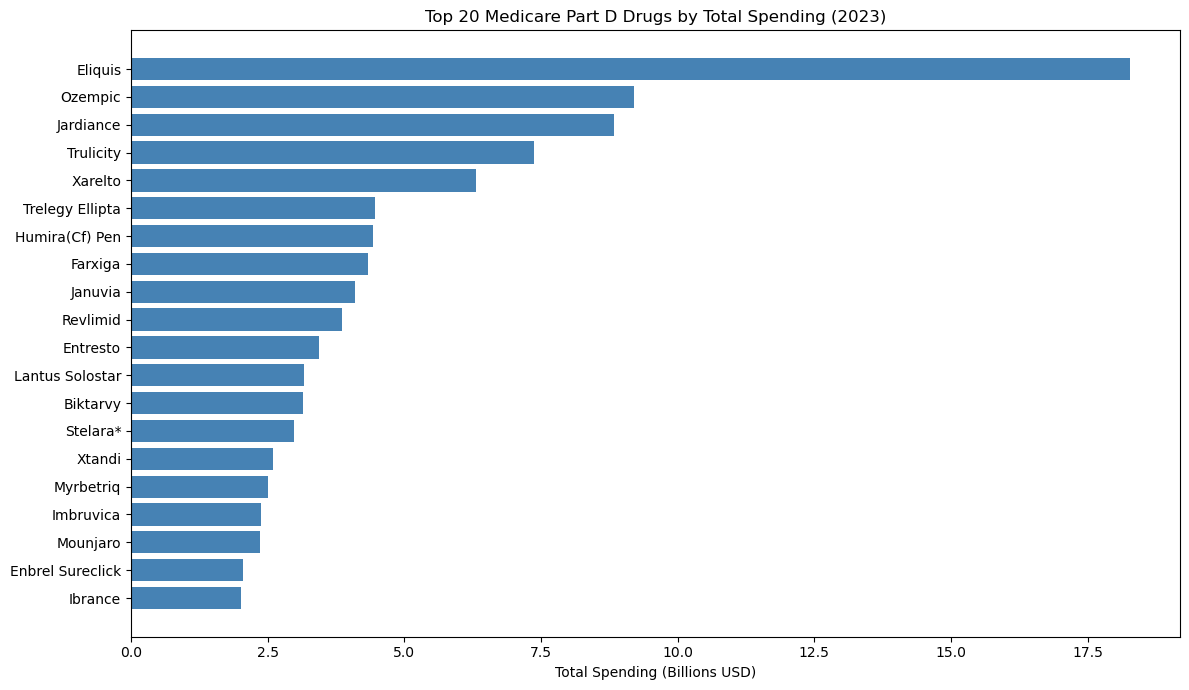

In [5]:
top20 = df_overall[['Brnd_Name', 'Gnrc_Name', 'Tot_Spndng_2023']] \
            .sort_values('Tot_Spndng_2023', ascending=False) \
            .head(20)

plt.figure(figsize=(12, 7))
plt.barh(top20['Brnd_Name'], top20['Tot_Spndng_2023'] / 1e9, color='steelblue')
plt.xlabel('Total Spending (Billions USD)')
plt.title('Top 20 Medicare Part D Drugs by Total Spending (2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_top20_spend.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Chronic disease medications dominate Medicare Part D spending.
# Two anticoagulants (Eliquis, Xarelto) and three diabetes drugs (Ozempic,
# Jardiance, Trulicity) lead total spend, reflecting both high unit costs
# and long-term daily use among elderly patients.

## 4. Top 20 Fastest Growing Drug Prices (CAGR 2019–2023)

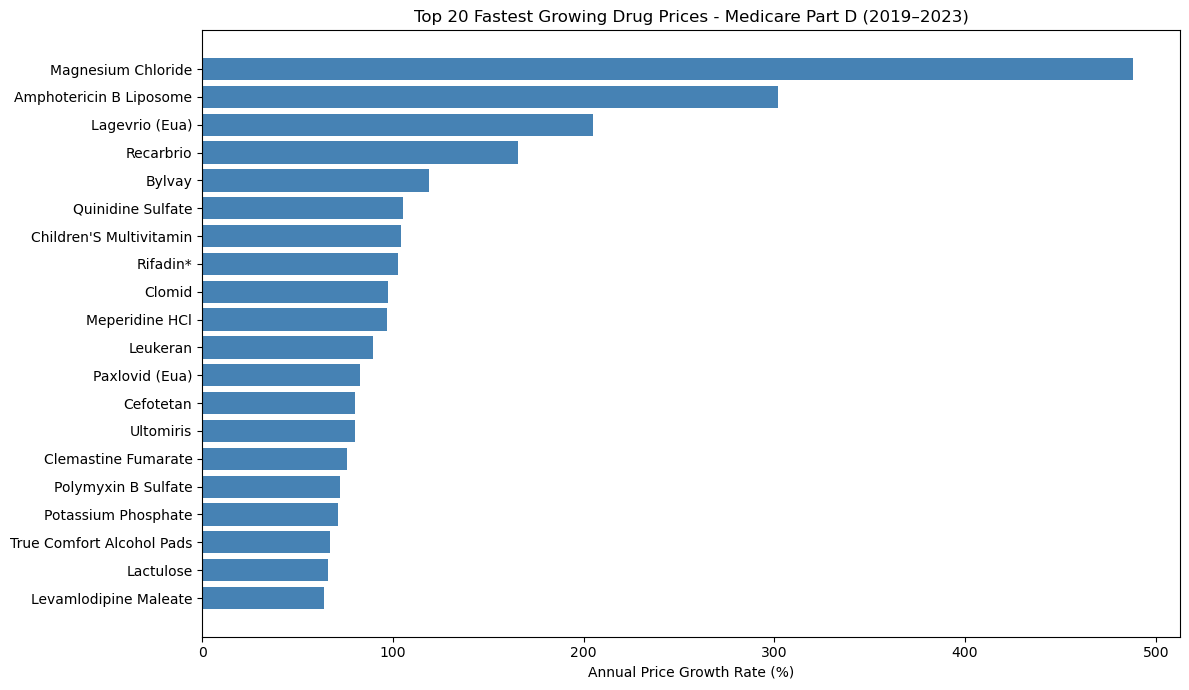

In [6]:
cagr = df_overall[['Brnd_Name', 'Gnrc_Name', 'CAGR_Avg_Spnd_Per_Dsg_Unt_19_23']] \
         .dropna() \
         .sort_values('CAGR_Avg_Spnd_Per_Dsg_Unt_19_23', ascending=False) \
         .head(20)

plt.figure(figsize=(12, 7))
plt.barh(cagr['Brnd_Name'], cagr['CAGR_Avg_Spnd_Per_Dsg_Unt_19_23'] * 100, color='steelblue')
plt.xlabel('Annual Price Growth Rate (%)')
plt.title('Top 20 Fastest Growing Drug Prices - Medicare Part D (2019–2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_price_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: The fastest price growth belongs to generic drugs, not brand-names.
# This reflects generic drug market consolidation and supply shortages —
# a counterintuitive but well-documented problem in US drug pricing.

## 5. Drug Price Trends Over Time (2019–2023)

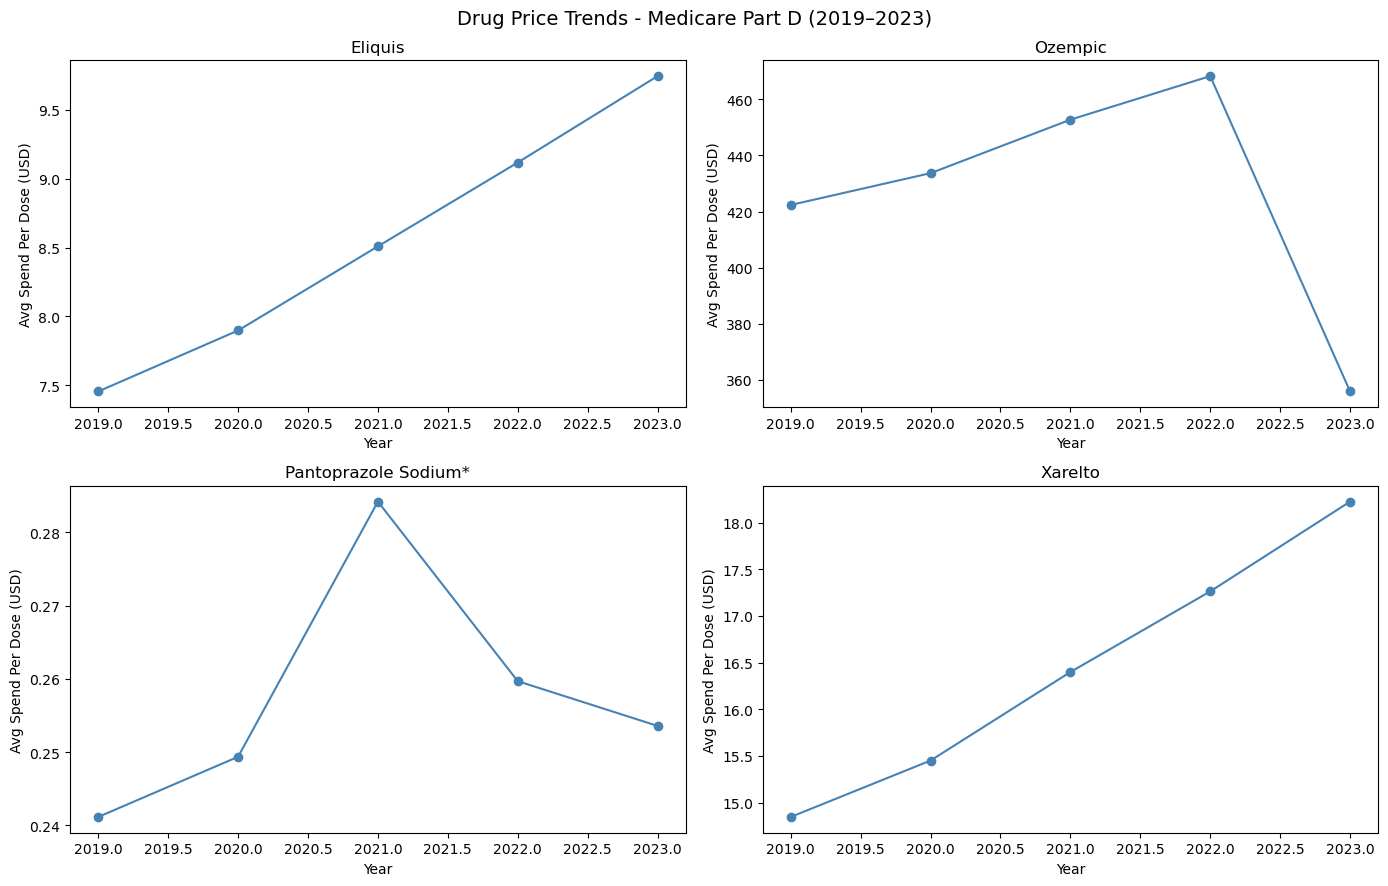

In [7]:
drugs_to_track = ['Eliquis', 'Ozempic', 'Xarelto', 'Pantoprazole Sodium*']

trends = df_overall[df_overall['Brnd_Name'].isin(drugs_to_track)].copy()

price_cols = ['Brnd_Name'] + [f'Avg_Spnd_Per_Dsg_Unt_Wghtd_{y}' for y in years]

trends_price = trends[price_cols] \
                .groupby('Brnd_Name') \
                .mean() \
                .reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, row in trends_price.iterrows():
    axes[i].plot(years, row[1:], marker='o', color='steelblue')
    axes[i].set_title(row['Brnd_Name'])
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Avg Spend Per Dose (USD)')

plt.suptitle('Drug Price Trends - Medicare Part D (2019–2023)', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Eliquis and Xarelto show steady predictable price increases each year.
# Ozempic peaked in 2022 then dropped sharply in 2023, consistent with the
# Inflation Reduction Act allowing Medicare to negotiate drug prices directly.
# Pantoprazole (generic) shows a volatile pattern typical of generic supply shocks.

## 6. Spending vs Beneficiaries — Two Types of Expensive Drugs

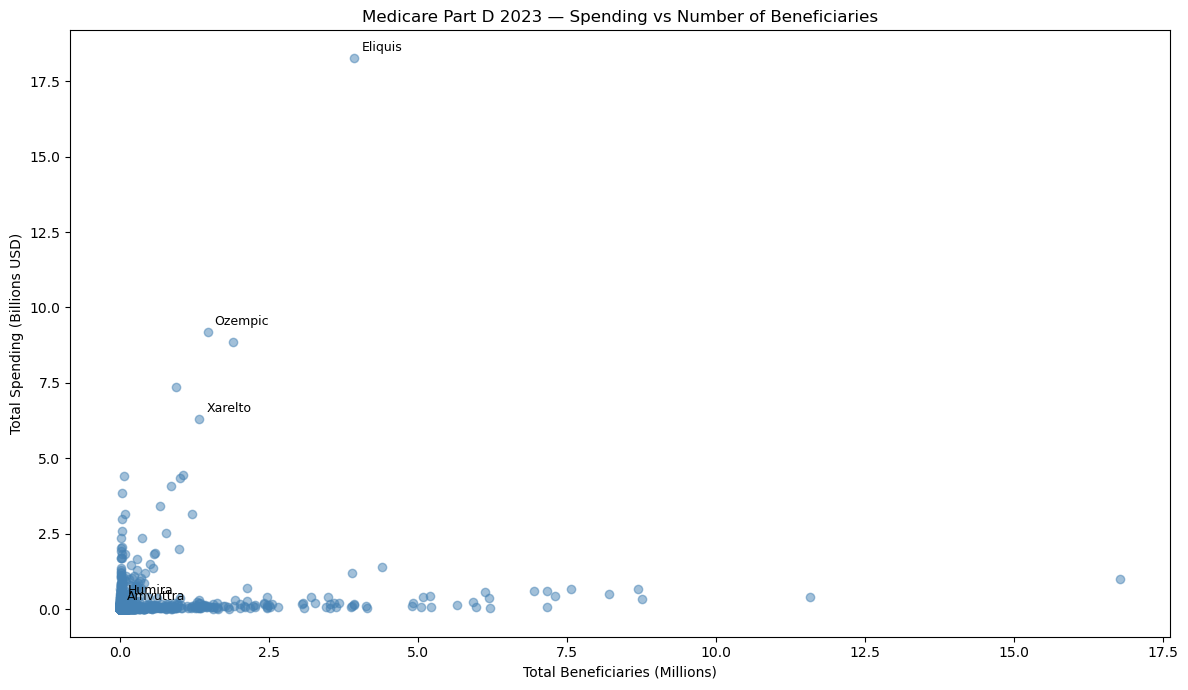

In [8]:
scatter_data = df_overall[['Brnd_Name', 'Tot_Spndng_2023', 'Tot_Benes_2023']].dropna()

plt.figure(figsize=(12, 7))
plt.scatter(
    scatter_data['Tot_Benes_2023'] / 1e6,
    scatter_data['Tot_Spndng_2023'] / 1e9,
    alpha=0.5, color='steelblue'
)

drugs_to_label = ['Eliquis', 'Ozempic', 'Xarelto', 'Amvuttra', 'Humira']
for _, row in scatter_data.iterrows():
    if row['Brnd_Name'] in drugs_to_label:
        plt.annotate(
            row['Brnd_Name'],
            xy=(row['Tot_Benes_2023'] / 1e6, row['Tot_Spndng_2023'] / 1e9),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )

plt.xlabel('Total Beneficiaries (Millions)')
plt.ylabel('Total Spending (Billions USD)')
plt.title('Medicare Part D 2023 — Spending vs Number of Beneficiaries')
plt.tight_layout()
plt.savefig('chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: There are two distinct categories of expensive drugs.
# High-volume drugs (Eliquis) are expensive because millions of patients use them daily.
# High-cost drugs (Amvuttra) are expensive per patient but affect very few people.
# These require completely different policy interventions.

## 7. Cost Burden Per Patient — The Hidden Orphan Drug Crisis

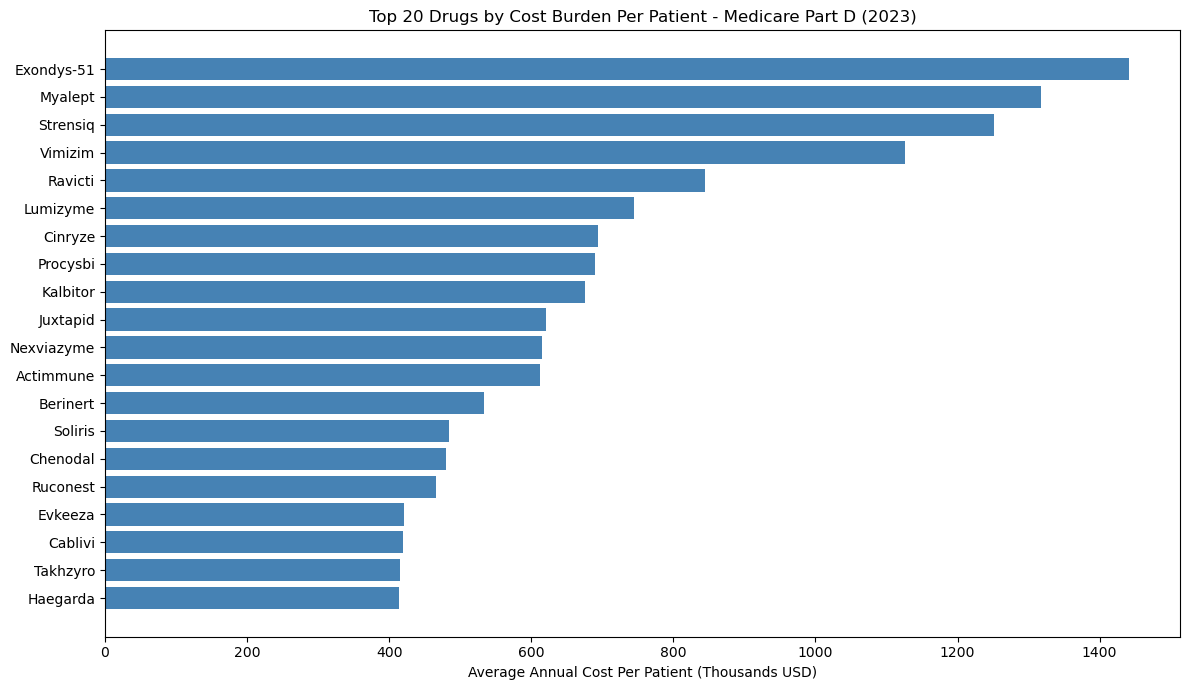

In [9]:
burden = df_overall[['Brnd_Name', 'Gnrc_Name', 'Tot_Spndng_2023', 'Tot_Benes_2023']].copy()
burden['Cost_Per_Patient'] = burden['Tot_Spndng_2023'] / burden['Tot_Benes_2023']

burden_top20 = burden.dropna() \
                     .sort_values('Cost_Per_Patient', ascending=False) \
                     .head(20)

plt.figure(figsize=(12, 7))
plt.barh(burden_top20['Brnd_Name'], burden_top20['Cost_Per_Patient'] / 1000, color='steelblue')
plt.xlabel('Average Annual Cost Per Patient (Thousands USD)')
plt.title('Top 20 Drugs by Cost Burden Per Patient - Medicare Part D (2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart5_cost_burden.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: The highest cost-burden drugs are entirely different from the
# highest total-spend drugs. Rare disease (orphan) drugs cost $400K-$1.4M
# per patient annually but affect too few patients to appear in aggregate
# spending charts. This creates a hidden affordability crisis for the
# small populations who need them most.

## 8. Brand vs Generic — A $225 Billion Gap

   Type  Total Spend (B)  Avg Cost Per Dose  Number of Drugs
  Brand       250.091404         662.939811             2997
Generic        25.833116          64.751944              601


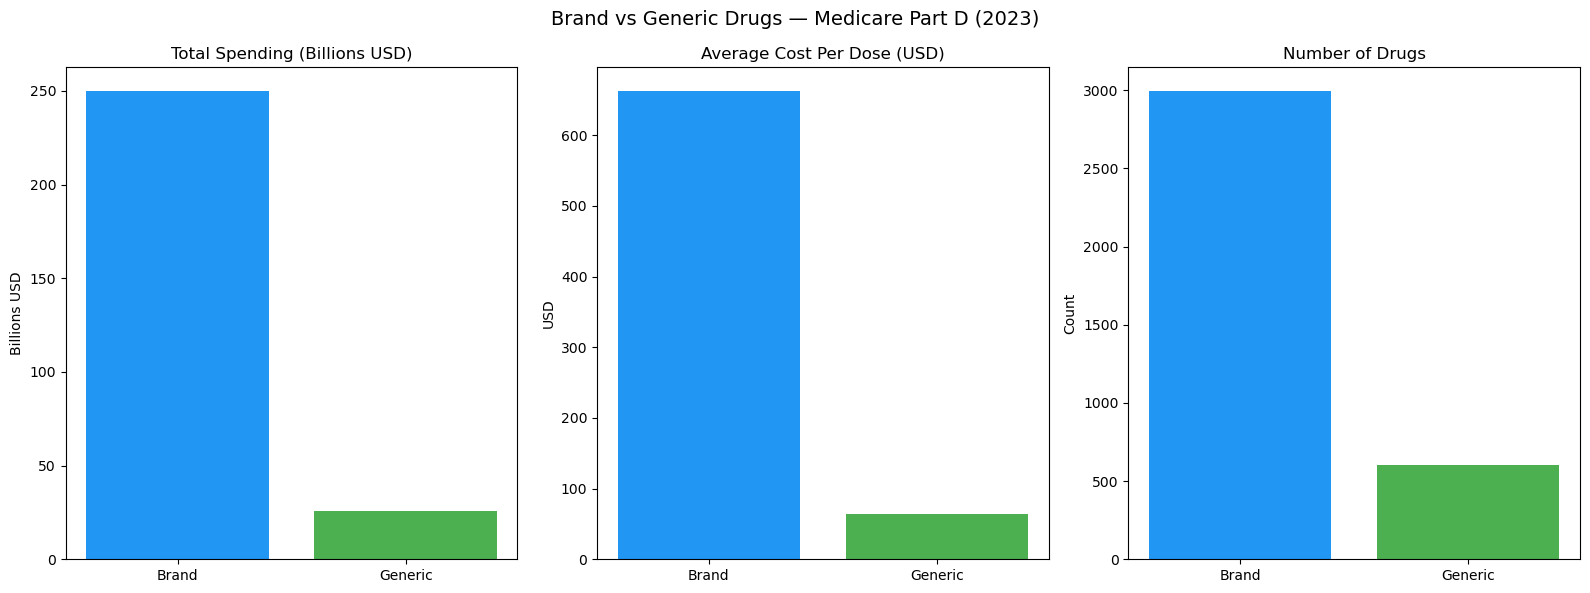

In [10]:
df_overall['Is_Generic'] = (
    df_overall['Brnd_Name'].str.lower() == df_overall['Gnrc_Name'].str.lower()
)

brand = df_overall[df_overall['Is_Generic'] == False]
generic = df_overall[df_overall['Is_Generic'] == True]

summary_df = pd.DataFrame({
    'Type': ['Brand', 'Generic'],
    'Total Spend (B)': [
        brand['Tot_Spndng_2023'].sum() / 1e9,
        generic['Tot_Spndng_2023'].sum() / 1e9
    ],
    'Avg Cost Per Dose': [
        brand['Avg_Spnd_Per_Dsg_Unt_Wghtd_2023'].mean(),
        generic['Avg_Spnd_Per_Dsg_Unt_Wghtd_2023'].mean()
    ],
    'Number of Drugs': [len(brand), len(generic)]
})

print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colors = ['#2196F3', '#4CAF50']

axes[0].bar(summary_df['Type'], summary_df['Total Spend (B)'], color=colors)
axes[0].set_title('Total Spending (Billions USD)')
axes[0].set_ylabel('Billions USD')

axes[1].bar(summary_df['Type'], summary_df['Avg Cost Per Dose'], color=colors)
axes[1].set_title('Average Cost Per Dose (USD)')
axes[1].set_ylabel('USD')

axes[2].bar(summary_df['Type'], summary_df['Number of Drugs'], color=colors)
axes[2].set_title('Number of Drugs')
axes[2].set_ylabel('Count')

plt.suptitle('Brand vs Generic Drugs — Medicare Part D (2023)', fontsize=14)
plt.tight_layout()
plt.savefig('chart6_brand_vs_generic.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Brand-name drugs account for 91% of total Medicare Part D spending
# despite generics being 10x cheaper per dose. With only 601 generic drugs
# vs 2,997 brand-name drugs in the system, there is significant room for
# policy intervention through generic substitution.

## 9. Conclusions

| Finding | Implication |
|---|---|
| Chronic disease drugs dominate total spend | Long-term medication management is Medicare's largest cost driver |
| Generic prices are most volatile | Market consolidation among generic manufacturers creates hidden cost risks |
| Ozempic price dropped in 2023 | Inflation Reduction Act price negotiation is showing measurable impact |
| Orphan drugs cost up to $1.4M per patient | Aggregate spending data masks catastrophic individual-level cost burdens |
| 91% of spend is on brand-name drugs | Aggressive generic substitution policy could significantly reduce Medicare costs |

---

**Data Source:** Centers for Medicare & Medicaid Services (CMS) Medicare Part D Drug Spending Dataset  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)